## XOR 문제 해결하기
MLP로 XOR 문제 해결 구현

**1. XOR 데이터 생성 (노이즈 추가)**

In [2]:
import torch

torch.manual_seed(42)
base_X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
base_Y = torch.tensor([[0.],[1.],[1.],[0.]])

# 샘플 수 늘리기 + 노이즈
n_per = 100
X = base_X.repeat_interleave(n_per, dim=0) + 0.10*torch.randn(4*n_per, 2)
Y = base_Y.repeat_interleave(n_per, dim=0)

**2. 로지스틱 회귀 모델 정의**

In [3]:
def sigmoid(z):
  return 1 / (1 + torch.exp(-z))

def bce_loss(p, y, eps=1e-7):
  return -(y*torch.log(p+eps) + (1-y)*torch.log(1-p+eps)).mean() # BCE 구현

w = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.5
epochs = 300
losses, accs = [], []


**3. 로지스틱 회귀 학습 루프**

In [4]:
for epoch in range(epochs):
  z = X @ w + b
  p = sigmoid(z)
  loss = bce_loss(p, Y)

  loss.backward()
  with torch.no_grad():
    w -= lr*w.grad
    b -= lr*b.grad
    w.grad.zero_(); b.grad.zero_()

    acc = ((p > 0.5).float() == Y).float().mean()
    losses.append(loss.item())
    accs.append(acc.item())

    if (epoch+1) % 50 == 0:
      print(f"Epoch {epoch+1:3d} | loss {loss.item():.4f} | acc {acc.item():.4f}")


Epoch  50 | loss 0.6950 | acc 0.3375
Epoch 100 | loss 0.6931 | acc 0.5025
Epoch 150 | loss 0.6929 | acc 0.5650
Epoch 200 | loss 0.6929 | acc 0.4975
Epoch 250 | loss 0.6929 | acc 0.5000
Epoch 300 | loss 0.6929 | acc 0.5000


**4. Loss/Acc 그래프 & 결정경계 확인**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54001 (\N{HANGUL SYLLABLE TIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

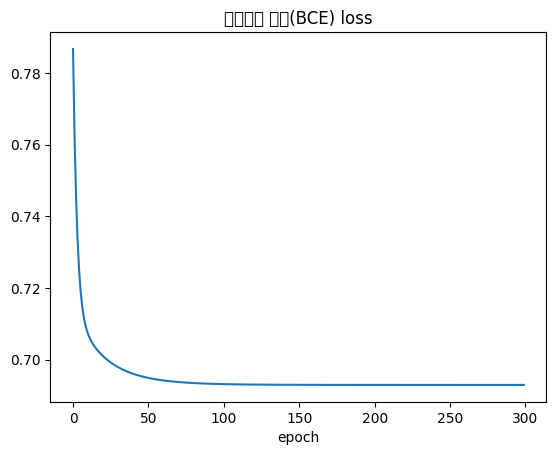

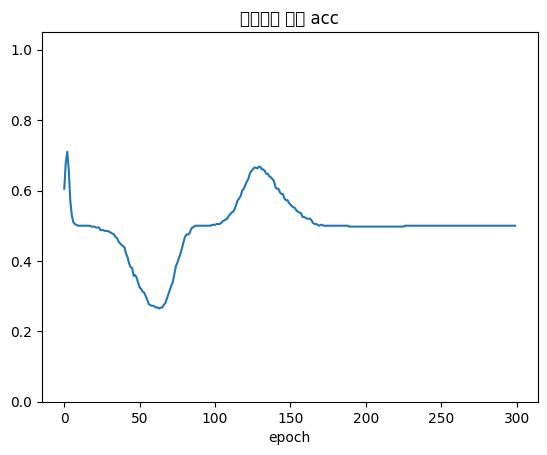

NameError: name 'plot_decision_boundary' is not defined

In [7]:
import matplotlib.pyplot as plt


plt.plot(losses); plt.title("로지스틱 회귀(BCE) loss"); plt.xlabel("epoch"); plt.show()
plt.plot(accs); plt.title("로지스틱 회귀 acc"); plt.xlabel("epoch"); plt.ylim(0,1.05); plt.show()

plot_decision_boundary(lambda G: sigmoid(G @ w + b), X, Y,
                       title="선형(로지스틱) 모델 결정경계: XOR에서 한계")


**5. MLP 파라미터 & Forward 정의**

In [8]:
torch.manual_seed(3)

hidden = 2

W1 = torch.randn(2, hidden, requires_grad=True)
b1 = torch.zeros(hidden, requires_grad=True)
W2 = torch.randn(hidden, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

def act(x):
  return torch.sigmoid(x)

def forward_logits(x):
  h = act(x @ W1 + b1)
  logit = h @ W2 + b2
  return logit, h

def bce_with_logits(logit, y):
  return F.binary_cross_entropy_with_logits(logit, y)

print(W1.shape, b1.shape, W2.shape, b2.shape)


torch.Size([2, 2]) torch.Size([2]) torch.Size([2, 1]) torch.Size([1])


**6. MLP 학습 루프 & 시각화**

Epoch  200 | loss 0.6929 | acc 0.2550
Epoch  400 | loss 0.6926 | acc 0.5000
Epoch  600 | loss 0.6920 | acc 0.6125
Epoch  800 | loss 0.6904 | acc 0.7150
Epoch 1000 | loss 0.6858 | acc 0.7325
Epoch 1200 | loss 0.6722 | acc 0.7450
Epoch 1400 | loss 0.6386 | acc 0.7475
Epoch 1600 | loss 0.5919 | acc 0.7500
Epoch 1800 | loss 0.5544 | acc 0.7500
Epoch 2000 | loss 0.5184 | acc 0.7500
Epoch 2200 | loss 0.4685 | acc 0.7500
Epoch 2400 | loss 0.3720 | acc 0.9225
Epoch 2600 | loss 0.2552 | acc 1.0000
Epoch 2800 | loss 0.1762 | acc 1.0000
Epoch 3000 | loss 0.1296 | acc 1.0000


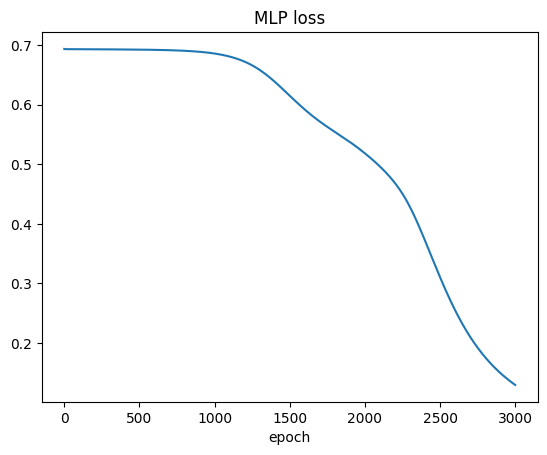

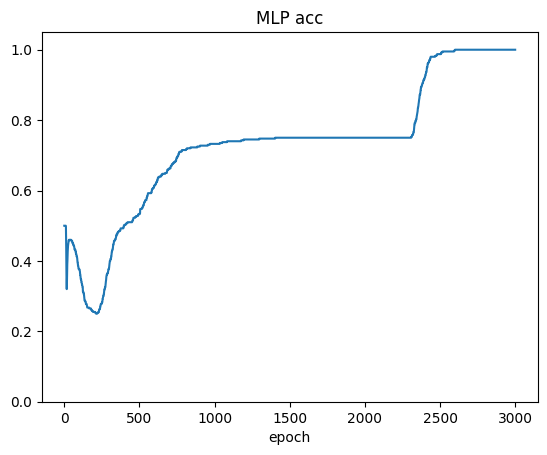

NameError: name 'plot_decision_boundary' is not defined

In [13]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from sklearn.datasets import make_moons

lr = 0.3
epochs = 3000
losses_mlp, accs_mlp = [], []
for epoch in range(epochs):
  logit, h = forward_logits(X)
  loss = bce_with_logits(logit, Y)

  loss.backward()
  with torch.no_grad():
    for p in [W1, b1, W2, b2]:
      p -= lr * p.grad
      p.grad.zero_()

    p = torch.sigmoid(logit)
    acc = ((p > 0.5).float() == Y).float().mean()
    losses_mlp.append(loss.item()); accs_mlp.append(acc.item())

    if (epoch+1) % 200 == 0:
      print(f"Epoch {epoch+1:4d} | loss {loss.item():.4f} | acc {acc.item():.4f}")

plt.plot(losses_mlp); plt.title("MLP loss"); plt.xlabel("epoch"); plt.show()
plt.plot(accs_mlp); plt.title("MLP acc"); plt.xlabel("epoch"); plt.ylim(0,1.05); plt.show()

plot_decision_boundary(lambda G: torch.sigmoid(forward_logits(G)[0]), X, Y,
                       title="MLP Decision Boundary")


**7. 활성화 함수 없는 MLP 실험**

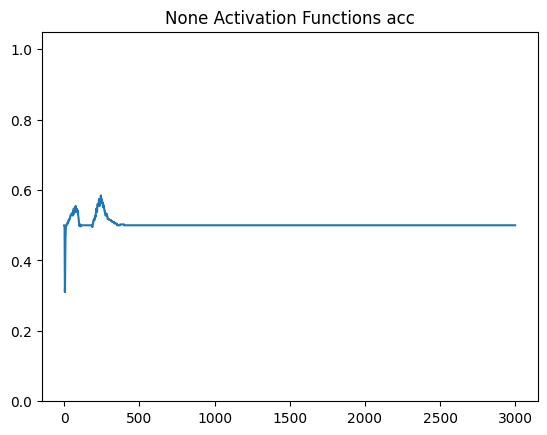

NameError: name 'plot_decision_boundary' is not defined

In [10]:
def identity(x): return x

def forward_logits_no_act(x):
  h = identity(x @ W1 + b1)
  logit = h @ W2 + b2
  return logit, h

lr = 0.3
epochs = 3000
losses_no, accs_no = [], []

for p in [W1, b1, W2, b2]:
  with torch.no_grad():
    p.copy_(torch.randn_like(p) * 0.5)

for epoch in range(epochs):
  logit, h = forward_logits_no_act(X)
  loss = bce_with_logits(logit, Y)

  loss.backward()
  with torch.no_grad():
    for p in [W1, b1, W2, b2]:
      p -= lr * p.grad
      p.grad.zero_()

  p = torch.sigmoid(logit)
  acc = ((p > 0.5).float() == Y).float().mean()
  losses_no.append(loss.item()); accs_no.append(acc.item())

plt.plot(accs_no); plt.title("None Activation Functions acc"); plt.ylim(0,1.05); plt.show()
plot_decision_boundary(lambda G: torch.sigmoid(forward_logits_no_act(G)[0]), X, Y,)


**8. 은닉층 출력 시각화**

https://docs.pytorch.org/docs/main/nn.html   
> 여기서 activation function 불러와서 다양한 활성화함수 시도해보기

ex. GELU는 torch.nn.GELU()로 클래스 불러와서 해야 함

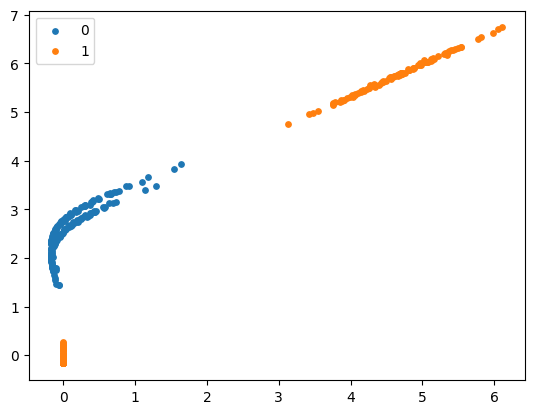

In [22]:
torch.manual_seed(0)
W1 = torch.randn(2, 2, requires_grad=True)
b1 = torch.zeros(2, requires_grad=True)
W2 = torch.randn(2, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

gelu = torch.nn.GELU()

def act(x): return gelu(x)
def forward_logits(x):
  h = act(x @ W1 + b1)
  return (h @ W2 + b2), h

lr = 0.5
for epoch in range(1500):
  logit, h = forward_logits(X)
  loss = F.binary_cross_entropy_with_logits(logit, Y)
  loss.backward()
  with torch.no_grad():
    for p in [W1, b1, W2, b2]:
      p -= lr * p.grad
      p.grad.zero_()

with torch.no_grad():
  _, h = forward_logits(X)
  plt.scatter(h[Y[:,0]==0,0].cpu(), h[Y[:,0]==0,1].cpu(), s=15, label="0")
  plt.scatter(h[Y[:,0]==1,0].cpu(), h[Y[:,0]==1,1].cpu(), s=15, label="1")
  plt.legend(); plt.show()


에폭마다 비교

In [28]:
torch.manual_seed(0)
W1_t = torch.randn(2, 2, requires_grad=True)
b1_t = torch.zeros(2, requires_grad=True)
W2_t = torch.randn(2, 1, requires_grad=True)
b2_t = torch.zeros(1, requires_grad=True)

def forward_logits_t(x):
  h_t = torch.relu(x @ W1_t + b1_t)
  return (h_t @ W2_t + b2_t), h_t

lr_t = 0.5
total_epochs = 1500
check_epochs = [0, 10, 50, 200, 800, 1500]
history_h = {}

with torch.no_grad():
  _, h0 = forward_logits_t(X)
  history_h[0] = h0.detach().cpu()

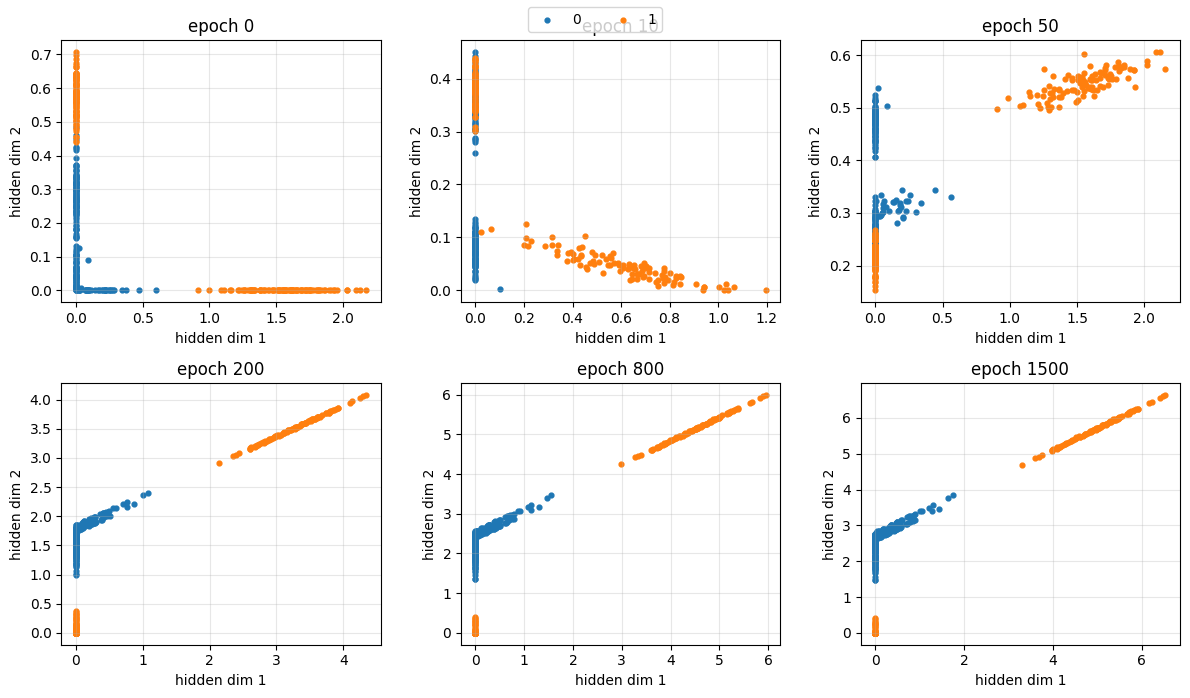

In [29]:
for epoch in range(1, total_epochs + 1):
  logit_t, h_t = forward_logits_t(X)
  loss_t = F.binary_cross_entropy_with_logits(logit_t, Y)

  loss_t.backward()
  with torch.no_grad():
    for p in [W1_t, b1_t, W2_t, b2_t]:
      p -= lr_t * p.grad
      p.grad.zero_()

    if epoch in check_epochs:
      _, h_now = forward_logits_t(X)
      history_h[epoch] = h_now.detach().cpu()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, e in zip(axes.ravel(), check_epochs):
  h_e = history_h[e]
  ax.scatter(h_e[Y[:,0]==0,0], h_e[Y[:,0]==0,1], s=12, label="0")
  ax.scatter(h_e[Y[:,0]==1,0], h_e[Y[:,0]==1,1], s=12, label="1")
  ax.set_title(f"epoch {e}")
  ax.set_xlabel("hidden dim 1")
  ax.set_ylabel("hidden dim 2")
  ax.grid(alpha=0.3)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout()
plt.show()


sigmoid: 초반에는 흔들리다가, 갈수록 안정되는 경향   
relu: 0 에서 꺾임

에폭마다 비교 (활성화 함수 이전 출력)

In [26]:
torch.manual_seed(0)
W1_t = torch.randn(2, 2, requires_grad=True)
b1_t = torch.zeros(2, requires_grad=True)
W2_t = torch.randn(2, 1, requires_grad=True)
b2_t = torch.zeros(1, requires_grad=True)

def forward_logits_t(x):
  z_t = x @ W1_t + b1_t # 활성화 이전 값 저장
  h_t = torch.relu(z_t)
  return (h_t @ W2_t + b2_t), z_t # z_t 반환

lr_t = 0.5
total_epochs = 1500
check_epochs = [0, 10, 50, 200, 800, 1500]
history_z = {}

with torch.no_grad():
  _, z0 = forward_logits_t(X)
  history_z[0] = z0.detach().cpu()

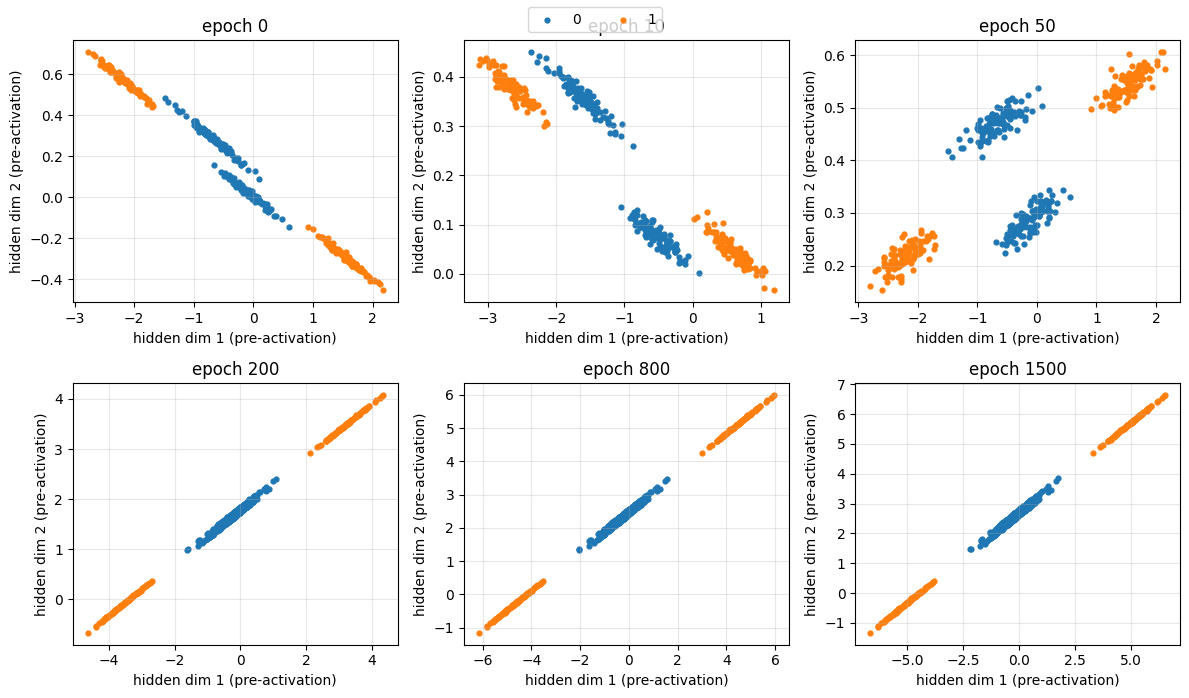

In [27]:
for epoch in range(1, total_epochs + 1):
  logit_t, z_t = forward_logits_t(X)
  loss_t = F.binary_cross_entropy_with_logits(logit_t, Y)

  loss_t.backward()
  with torch.no_grad():
    for p in [W1_t, b1_t, W2_t, b2_t]:
      p -= lr_t * p.grad
      p.grad.zero_()

      if epoch in check_epochs:
        _, z_now = forward_logits_t(X)
        history_z[epoch] = z_now.detach().cpu()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, e in zip(axes.ravel(), check_epochs):
  z_e = history_z[e]
  ax.scatter(z_e[Y[:,0]==0,0], z_e[Y[:,0]==0,1], s=12, label="0")
  ax.scatter(z_e[Y[:,0]==1,0], z_e[Y[:,0]==1,1], s=12, label="1")
  ax.set_title(f"epoch {e}")
  ax.set_xlabel("hidden dim 1 (pre-activation)")
  ax.set_ylabel("hidden dim 2 (pre-activation)")
  ax.grid(alpha=0.3)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout()
plt.show()

## 손실함수 심화 이해
이진분류 + Sigmoid + BCE를 코드로 구현하기

**CrossEntropy 직접 계산**

In [30]:
# 정답: 클래스 0
P = torch.tensor([1.0, 0.0, 0.0]) # 정답이 1, 0, 0
Q_good = torch.tensor([0.9, 0.05, 0.05]) # 정답에 큰 값, 오답에 작은 값
Q_bad = torch.tensor([0.2, 0.4, 0.4]) # 오답에 큰 값, 정답에 작은 값

def cross_entropy(P, Q, eps=1e-9):
  return -(P * torch.log(Q + eps)).sum()

print("좋은 예측 CE:", cross_entropy(P, Q_good).item())
print("나쁜 예측 CE:", cross_entropy(P, Q_bad).item())

좋은 예측 CE: 0.10536054521799088
나쁜 예측 CE: 1.6094379425048828


In [32]:
# 정답: 클래스 0
P = torch.tensor([1.0, 0.0, 0.0]) # 정답이 1, 0, 0
Q_good = torch.tensor([0.9, 0.55, 0.05]) # 정답에 큰 값, 오답에 작은 값
Q_bad = torch.tensor([0.2, 0.4, 0.9]) # 오답에 큰 값, 정답에 작은 값

def cross_entropy(P, Q, eps=1e-9):
  return -(P * torch.log(Q + eps)).sum()

print("좋은 예측 CE:", cross_entropy(P, Q_good).item())
print("나쁜 예측 CE:", cross_entropy(P, Q_bad).item())

좋은 예측 CE: 0.10536054521799088
나쁜 예측 CE: 1.6094379425048828


정답값에 대한 확률만 취하게 됨   

오답값이 어떤 인코딩을 해주던지 관계 없음 !!    
(오답에 대한 확률을 바꾸더라도 동일한 결과를 가짐   
위 값이랑 아래 값이랑 동일)

**엔트로피 - CrossEntropy - KL Divergence**

In [31]:
def entropy(P, eps=1e-9):
  return -(P * torch.log(P + eps)).sum()

def cross_ent(P, Q, eps=1e-9): # torch 함수에 존재함
  return -(P * torch.log(Q + eps)).sum()

def kl(P, Q, eps=1e-9):
  return (P * torch.log((P + eps) / (Q + eps))).sum()

P = torch.tensor([0.5, 0.25, 0.25])
Q = torch.tensor([0.6, 0.2, 0.2])

HP = entropy(P)
HPQ = cross_ent(P, Q)
KL = kl(P, Q)

print("H(P)    =", HP.item())
print("H(P,Q)  =", HPQ.item())
print("KL(P||Q)=", KL.item())
print("H(P)+KL =", (HP+KL).item())

H(P)    = 1.0397207736968994
H(P,Q)  = 1.0601317882537842
KL(P||Q)= 0.020410984754562378
H(P)+KL = 1.0601317882537842


**|H(P) - H(P,Q)| = KL(P||Q)**   

**BCE vs MSE 그래디언트 비교**

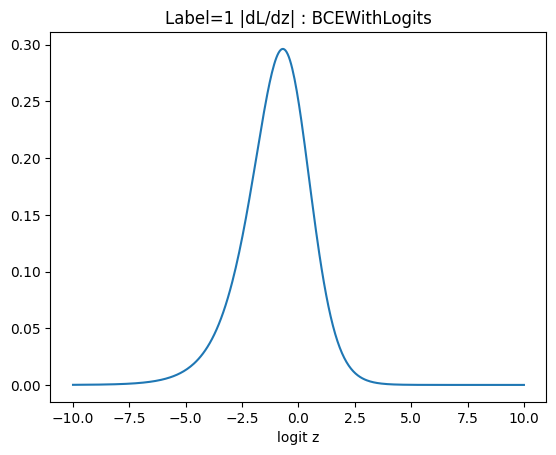

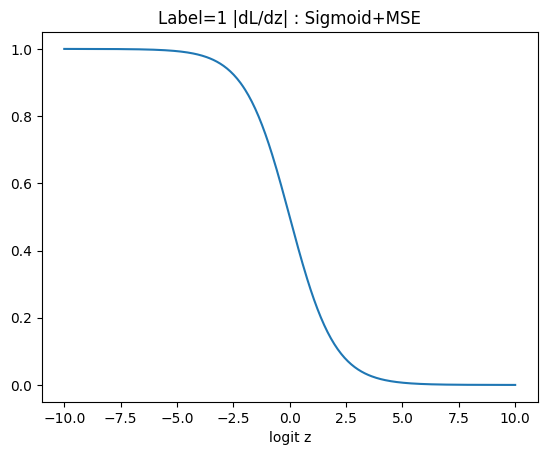

In [34]:
z = torch.linspace(-10, 10, 400)
p = torch.sigmoid(z)
y1 = torch.ones_like(z) # 정답=1 가정

grad_mse = (p - y1).abs()
grad_bce = (2*(p - y1) * p * (1-p)).abs()

plt.plot(z, grad_bce); plt.title("Label=1 |dL/dz| : BCEWithLogits"); plt.xlabel("logit z"); plt.show()
plt.plot(z, grad_mse); plt.title("Label=1 |dL/dz| : Sigmoid+MSE"); plt.xlabel("logit z"); plt.show()

MSE   
-> 초반에는 loss가 높음 (잘 못 맞춤)   
-> 불안정성

sigmoid 쓸 때 MSE 쓰면 초반 학습에서 불안정하니까, BCE를 써야 함

sigmoid의 결과가 확률로 나오니까, 확률분포를 결과값으로 내는 loss 함수를 써야함(CrossEntropy, KL Divergence)